# CVAE 학습

`CVAE_학습데이터_생성.ipynb`가 만든 `.npz` 샘플을 읽는다.

- condition image: `(N, 6, 256, 256)`
- target image: `(N, 4, 256, 256)`
- metadata: `(N, 4)`

In [11]:
# 필요하면 먼저 실행
%pip install torch numpy

from pathlib import Path
import json
import random
import pandas as pd

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

Note: you may need to restart the kernel to use updated packages.


In [2]:
SEED = 20260522
BATCH_SIZE = 4
EPOCHS = 50
LEARNING_RATE = 2e-4
BETA = 1e-3
LATENT_DIM = 64
WIDTH = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path.cwd()
if DATA_DIR.name != "학습데이터":
    DATA_DIR = DATA_DIR / "학습데이터"
RUN_DIR = DATA_DIR / "runs"
RUN_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONDITION_CHANNELS = ["elevation", "slope", "aspect_sin", "aspect_cos", "hillshade_landsat", "ndvi"]
TARGET_CHANNELS = ["O3", "PM10", "PM25", "lst_k"]
train_paths = sorted((DATA_DIR / "samples" / "train").glob("*.npz"))
val_paths = sorted((DATA_DIR / "samples" / "val").glob("*.npz"))
print("device", DEVICE, "train", len(train_paths), "val", len(val_paths))

device cpu train 1128 val 192


In [3]:
def update_bounds(minima, maxima, values, mask=None):
    for idx in range(values.shape[0]):
        valid = values[idx][mask[idx]] if mask is not None else values[idx].ravel()
        valid = valid[np.isfinite(valid)]
        if valid.size:
            minima[idx] = min(minima[idx], float(valid.min()))
            maxima[idx] = max(maxima[idx], float(valid.max()))

def compute_stats(paths):
    if not paths:
        raise FileNotFoundError("train samples are empty")
    cmin, cmax = np.full(6, np.inf), np.full(6, -np.inf)
    tmin, tmax = np.full(4, np.inf), np.full(4, -np.inf)
    for path in paths:
        with np.load(path) as sample:
            update_bounds(cmin, cmax, sample["condition"])
            update_bounds(tmin, tmax, sample["target"], sample["target_mask"])
    return {
        "condition": {name: {"min": float(cmin[i]), "max": float(cmax[i])} for i, name in enumerate(CONDITION_CHANNELS)},
        "target": {name: {"min": float(tmin[i]), "max": float(tmax[i])} for i, name in enumerate(TARGET_CHANNELS)},
    }

stats_path = DATA_DIR / "normalization_stats.json"
stats = json.loads(stats_path.read_text(encoding="utf-8")) if stats_path.exists() else compute_stats(train_paths)
stats_path.write_text(json.dumps(stats, indent=2), encoding="utf-8")
stats

{'condition': {'elevation': {'min': 3.0, 'max': 424.61749267578125},
  'slope': {'min': 0.0, 'max': 39.0},
  'aspect_sin': {'min': -1.0, 'max': 1.0},
  'aspect_cos': {'min': -1.0, 'max': 1.0},
  'hillshade_landsat': {'min': 76.0, 'max': 255.0},
  'ndvi': {'min': -0.4084353744983673, 'max': 0.7731338739395142}},
 'target': {'O3': {'min': 0.004704046994447708, 'max': 0.06528259813785553},
  'PM10': {'min': 27.001245498657227, 'max': 151.99908447265625},
  'PM25': {'min': 15.001326560974121, 'max': 68.9979248046875},
  'lst_k': {'min': 278.666015625, 'max': 318.9336853027344}}}

In [4]:
def minmax(values, channel_stats, names):
    out = values.astype(np.float32, copy=True)
    for idx, name in enumerate(names):
        lo, hi = channel_stats[name]["min"], channel_stats[name]["max"]
        out[idx] = 0.0 if hi - lo <= 1e-12 else (out[idx] - lo) / (hi - lo)
    return out

class PatchDataset(Dataset):
    def __init__(self, paths, stats):
        self.paths = paths
        self.stats = stats
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        with np.load(self.paths[idx]) as sample:
            return {
                "condition": torch.from_numpy(minmax(sample["condition"], self.stats["condition"], CONDITION_CHANNELS)),
                "target": torch.from_numpy(minmax(sample["target"], self.stats["target"], TARGET_CHANNELS)),
                "target_mask": torch.from_numpy(sample["target_mask"]),
                "meta": torch.from_numpy(sample["meta"].astype(np.float32)),
            }

train_loader = DataLoader(PatchDataset(train_paths, stats), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(PatchDataset(val_paths, stats), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [5]:
class DownBlock(nn.Sequential):
    def __init__(self, in_ch, out_ch):
        super().__init__(nn.Conv2d(in_ch, out_ch, 4, 2, 1), nn.GroupNorm(min(8, out_ch), out_ch), nn.SiLU(inplace=True))

class UpBlock(nn.Sequential):
    def __init__(self, in_ch, out_ch):
        super().__init__(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1), nn.GroupNorm(min(8, out_ch), out_ch), nn.SiLU(inplace=True))

class EnvironmentalCVAE(nn.Module):
    def __init__(self, condition_ch=6, target_ch=4, meta_dim=4, latent_dim=64, width=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.condition_encoder = nn.Sequential(DownBlock(condition_ch, width), DownBlock(width, width*2), DownBlock(width*2, width*4), DownBlock(width*4, width*8), DownBlock(width*8, width*8))
        self.posterior_encoder = nn.Sequential(DownBlock(condition_ch + target_ch, width), DownBlock(width, width*2), DownBlock(width*2, width*4), DownBlock(width*4, width*8), DownBlock(width*8, width*8))
        flat = width * 8 * 8 * 8
        self.posterior_head = nn.Sequential(nn.Linear(flat + meta_dim, width*16), nn.SiLU(inplace=True))
        self.mu = nn.Linear(width*16, latent_dim)
        self.logvar = nn.Linear(width*16, latent_dim)
        self.latent_map = nn.Sequential(nn.Linear(latent_dim + meta_dim, flat), nn.SiLU(inplace=True))
        self.decoder = nn.Sequential(UpBlock(width*16, width*8), UpBlock(width*8, width*4), UpBlock(width*4, width*2), UpBlock(width*2, width), UpBlock(width, width), nn.Conv2d(width, target_ch, 3, padding=1))
    def encode(self, condition, target, meta):
        h = self.posterior_encoder(torch.cat([condition, target], dim=1)).flatten(1)
        h = self.posterior_head(torch.cat([h, meta], dim=1))
        return self.mu(h), self.logvar(h).clamp(-20.0, 10.0)
    def decode(self, condition, meta, latent):
        c = self.condition_encoder(condition)
        z = self.latent_map(torch.cat([latent, meta], dim=1)).view(condition.shape[0], -1, 8, 8)
        return self.decoder(torch.cat([c, z], dim=1))
    def forward(self, condition, target, meta):
        mu, logvar = self.encode(condition, target, meta)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(condition, meta, z), mu, logvar
    @torch.no_grad()
    def sample(self, condition, meta):
        return self.decode(condition, meta, torch.randn(condition.shape[0], self.latent_dim, device=condition.device))

def masked_cvae_loss(pred, target, mask, mu, logvar, beta):
    mask = mask.to(pred.dtype)
    recon = ((pred - target).square() * mask).sum() / mask.sum().clamp_min(1.0)
    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.square() - logvar.exp(), dim=1))
    return recon + beta * kl, recon, kl

model = EnvironmentalCVAE(latent_dim=LATENT_DIM, width=WIDTH).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
sum(p.numel() for p in model.parameters())

15877700

In [6]:
def run_epoch(loader, training):
    model.train(training)
    totals = {"loss": 0.0, "reconstruction": 0.0, "kl": 0.0}
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch in loader:
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            pred, mu, logvar = model(batch["condition"], batch["target"], batch["meta"])
            loss, recon, kl = masked_cvae_loss(pred, batch["target"], batch["target_mask"], mu, logvar, BETA)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
            totals["loss"] += float(loss.detach())
            totals["reconstruction"] += float(recon.detach())
            totals["kl"] += float(kl.detach())
    return {key: value / max(len(loader), 1) for key, value in totals.items()}

# 샘플이 생긴 뒤 실행
history = []
best = float("inf")
for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(val_loader, training=False) if len(val_paths) else {}
    row = {"epoch": epoch, "train": train_metrics, "val": val_metrics}
    history.append(row)
    score = val_metrics.get("loss", train_metrics["loss"])
    checkpoint = {"epoch": epoch, "model": model.state_dict(), "optimizer": optimizer.state_dict(), "normalization_stats": stats}
    torch.save(checkpoint, RUN_DIR / "latest.pt")
    if score < best:
        best = score
        torch.save(checkpoint, RUN_DIR / "best.pt")
    print(row)

(RUN_DIR / "metrics.json").write_text(json.dumps(history, indent=2), encoding="utf-8")

{'epoch': 1, 'train': {'loss': 0.0816567902790105, 'reconstruction': 0.08158482638920875, 'kl': 0.07196420922558358}, 'val': {'loss': 0.0636150698022296, 'reconstruction': 0.06350851326715201, 'kl': 0.10655594958613317}}
{'epoch': 2, 'train': {'loss': 0.05670898483656611, 'reconstruction': 0.05668481266958282, 'kl': 0.024172213747569008}, 'val': {'loss': 0.060197078894513346, 'reconstruction': 0.060188729354801275, 'kl': 0.008349517825990915}}
{'epoch': 3, 'train': {'loss': 0.053742646612887475, 'reconstruction': 0.0536836841744734, 'kl': 0.05896238758103222}, 'val': {'loss': 0.05559344548964873, 'reconstruction': 0.055522399566446744, 'kl': 0.07104620197787881}}
{'epoch': 4, 'train': {'loss': 0.052196000184176874, 'reconstruction': 0.051966302463428135, 'kl': 0.2296978490995177}, 'val': {'loss': 0.051365452100678034, 'reconstruction': 0.05077444645576179, 'kl': 0.591005752949665}}
{'epoch': 5, 'train': {'loss': 0.045724767435289235, 'reconstruction': 0.043675070427067524, 'kl': 2.0496

14513

# 검증 / 테스트 평가

학습이 끝난 뒤 `best.pt`를 불러와 validation/test split의 채널별 RMSE, MAE를 계산하고 샘플 예측 이미지를 저장한다.

In [7]:
# best checkpoint 로드
CHECKPOINT_PATH = RUN_DIR / "best.pt"
if not CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH = RUN_DIR / "latest.pt"

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model"])
model.eval()
print("loaded", CHECKPOINT_PATH)
print("epoch", checkpoint.get("epoch"))

test_paths = sorted((DATA_DIR / "samples" / "test").glob("*.npz"))
test_loader = DataLoader(PatchDataset(test_paths, stats), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("val", len(val_paths), "test", len(test_paths))


loaded c:\Users\shinh\eigenspace\Workspace\26.05_MLproj\학습데이터\runs\best.pt
epoch 38
val 192 test 263


In [12]:
def denormalize(values, channel_stats, names):
    out = values.astype(np.float32, copy=True)
    for idx, name in enumerate(names):
        lo, hi = channel_stats[name]["min"], channel_stats[name]["max"]
        out[idx] = out[idx] * (hi - lo) + lo
    return out

SAVE_PREDICTIONS = False
MAX_SAVED_PREDICTIONS_PER_SPLIT = 5

@torch.no_grad()
def collect_predictions(paths, loader, split_name):
    rows = []
    pred_dir = RUN_DIR / "predictions" / split_name
    saved_predictions = 0
    if SAVE_PREDICTIONS:
        pred_dir.mkdir(parents=True, exist_ok=True)
    sample_idx = 0
    for batch in loader:
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        pred, mu, logvar = model(batch["condition"], batch["target"], batch["meta"])
        pred_np = pred.detach().cpu().numpy()
        target_np = batch["target"].detach().cpu().numpy()
        mask_np = batch["target_mask"].detach().cpu().numpy().astype(bool)
        for b in range(pred_np.shape[0]):
            source_path = paths[sample_idx]
            pred_denorm = denormalize(pred_np[b], stats["target"], TARGET_CHANNELS)
            target_denorm = denormalize(target_np[b], stats["target"], TARGET_CHANNELS)
            for ch, name in enumerate(TARGET_CHANNELS):
                valid = mask_np[b, ch]
                diff = pred_denorm[ch][valid] - target_denorm[ch][valid]
                rows.append({
                    "split": split_name,
                    "file": source_path.name,
                    "channel": name,
                    "rmse": float(np.sqrt(np.mean(diff ** 2))) if diff.size else np.nan,
                    "mae": float(np.mean(np.abs(diff))) if diff.size else np.nan,
                    "bias": float(np.mean(diff)) if diff.size else np.nan,
                    "valid_fraction": float(valid.mean()),
                })
            if SAVE_PREDICTIONS and saved_predictions < MAX_SAVED_PREDICTIONS_PER_SPLIT:
                np.savez_compressed(pred_dir / source_path.name, prediction=pred_denorm, target=target_denorm, target_mask=mask_np[b], target_channels=TARGET_CHANNELS)
                saved_predictions += 1
            sample_idx += 1
    return pd.DataFrame(rows)

val_metrics_df = collect_predictions(val_paths, val_loader, "val") if len(val_paths) else pd.DataFrame()
test_metrics_df = collect_predictions(test_paths, test_loader, "test") if len(test_paths) else pd.DataFrame()
metrics_df = pd.concat([val_metrics_df, test_metrics_df], ignore_index=True)
metrics_df.to_csv(RUN_DIR / "val_test_metrics_by_sample.csv", index=False)
metrics_df.groupby(["split", "channel"])[["rmse", "mae", "bias", "valid_fraction"]].mean()


rmse       mae      bias  valid_fraction
split channel                                               
test  O3        0.013758  0.012834 -0.009676        1.000000
      PM10     11.665303  9.562852 -0.646153        1.000000
      PM25      6.351383  5.481442 -2.507400        1.000000
      lst_k     5.465806  4.760891 -2.119909        0.858794
val   O3        0.008242  0.007608  0.000493        1.000000
      PM10     10.527337  9.423633  0.257006        1.000000
      PM25      6.180383  5.392496 -1.369478        1.000000
      lst_k     4.011519  3.420266  0.755091        0.916978

In [13]:
# 요약 metric 저장
summary_df = metrics_df.groupby(["split", "channel"])[["rmse", "mae", "bias", "valid_fraction"]].mean().reset_index()
summary_df.to_csv(RUN_DIR / "val_test_metrics_summary.csv", index=False)
summary_df


,split,channel,rmse,mae,bias,valid_fraction
0,test,O3,0.013758,0.012834,-0.009676,1.000000
1,test,PM10,11.665303,9.562852,-0.646153,1.000000
2,test,PM25,6.351383,5.481442,-2.507400,1.000000
3,test,lst_k,5.465806,4.760891,-2.119909,0.858794
4,val,O3,0.008242,0.007608,0.000493,1.000000
5,val,PM10,10.527337,9.423633,0.257006,1.000000
6,val,PM25,6.180383,5.392496,-1.369478,1.000000
7,val,lst_k,4.011519,3.420266,0.755091,0.916978


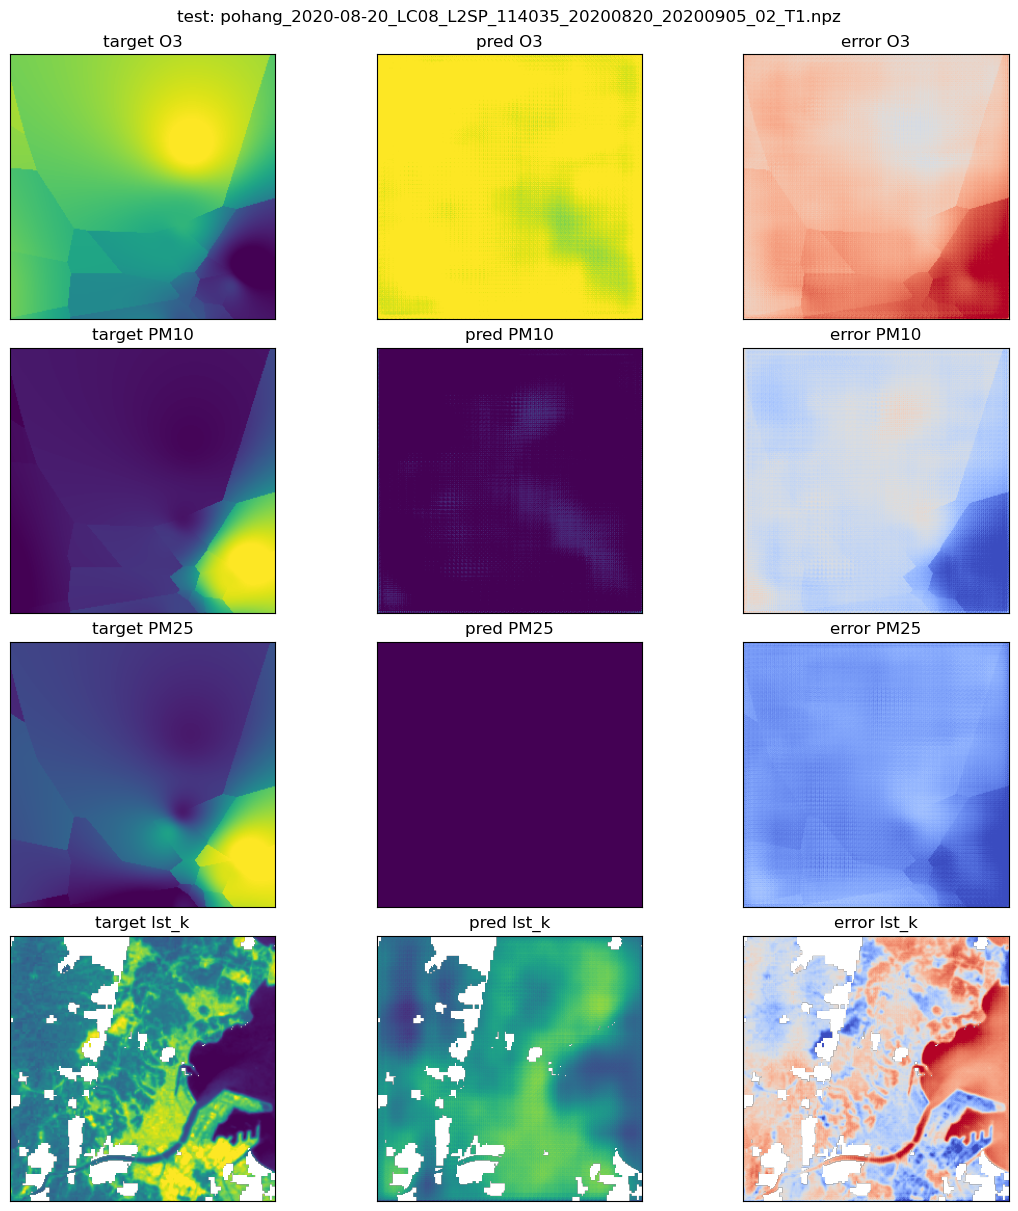

c:\Users\shinh\eigenspace\Workspace\26.05_MLproj\학습데이터\runs\prediction_preview_test_0.png


In [14]:
# 샘플 시각화: target / prediction / error
import matplotlib.pyplot as plt

def predict_one_sample(sample_path):
    one_loader = DataLoader(PatchDataset([sample_path], stats), batch_size=1, shuffle=False, num_workers=0)
    batch = next(iter(one_loader))
    batch = {key: value.to(DEVICE) for key, value in batch.items()}
    with torch.no_grad():
        pred, mu, logvar = model(batch["condition"], batch["target"], batch["meta"])
    pred_denorm = denormalize(pred.detach().cpu().numpy()[0], stats["target"], TARGET_CHANNELS)
    target_denorm = denormalize(batch["target"].detach().cpu().numpy()[0], stats["target"], TARGET_CHANNELS)
    mask = batch["target_mask"].detach().cpu().numpy()[0].astype(bool)
    return pred_denorm, target_denorm, mask

def plot_prediction_sample(split_name="test", sample_number=0):
    split_paths = sorted((DATA_DIR / "samples" / split_name).glob("*.npz"))
    if not split_paths:
        raise FileNotFoundError(f"no samples for {split_name}")
    sample_path = split_paths[sample_number]
    pred, target, mask = predict_one_sample(sample_path)
    fig, axes = plt.subplots(len(TARGET_CHANNELS), 3, figsize=(11, 12), constrained_layout=True)
    for ch, name in enumerate(TARGET_CHANNELS):
        truth = np.where(mask[ch], target[ch], np.nan)
        estimate = np.where(mask[ch], pred[ch], np.nan)
        error = estimate - truth
        vmin, vmax = np.nanpercentile(truth, [2, 98])
        err_lim = np.nanpercentile(np.abs(error), 98)
        axes[ch, 0].imshow(truth, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[ch, 0].set_title(f"target {name}")
        axes[ch, 1].imshow(estimate, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[ch, 1].set_title(f"pred {name}")
        axes[ch, 2].imshow(error, cmap="coolwarm", vmin=-err_lim, vmax=err_lim)
        axes[ch, 2].set_title(f"error {name}")
        for ax in axes[ch]:
            ax.set_xticks([])
            ax.set_yticks([])
    fig.suptitle(f"{split_name}: {sample_path.name}")
    out = RUN_DIR / f"prediction_preview_{split_name}_{sample_number}.png"
    fig.savefig(out, dpi=160)
    plt.show()
    print(out)

plot_prediction_sample("test", 0)


# 반사실 생성용 기본 함수

같은 latent `z`로 baseline condition과 수정 condition을 비교할 때 사용한다. 예를 들어 NDVI만 바꾼 `condition_cf`를 넣으면 `target_cf - target_base`를 계산할 수 있다.

In [15]:
@torch.no_grad()
def decode_with_fixed_z(condition_np, meta_np, z=None):
    condition = torch.from_numpy(condition_np[None].astype(np.float32)).to(DEVICE)
    condition = torch.from_numpy(minmax(condition_np, stats["condition"], CONDITION_CHANNELS)[None]).to(DEVICE)
    meta = torch.from_numpy(meta_np[None].astype(np.float32)).to(DEVICE)
    if z is None:
        z = torch.randn(1, model.latent_dim, device=DEVICE)
    pred = model.decode(condition, meta, z).detach().cpu().numpy()[0]
    return denormalize(pred, stats["target"], TARGET_CHANNELS), z

def counterfactual_ndvi(sample_path, ndvi_cf):
    with np.load(sample_path) as sample:
        condition_base = sample["condition"].copy()
        meta = sample["meta"].astype(np.float32)
    condition_cf = condition_base.copy()
    condition_cf[5] = ndvi_cf.astype(np.float32)
    base, z = decode_with_fixed_z(condition_base, meta)
    cf, _ = decode_with_fixed_z(condition_cf, meta, z=z)
    return base, cf, cf - base
